In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core.reshape.merge import merge
import seaborn as sns

# Exploring the Association Between Obesity and Mental Health: A Cross-Country Analysis of Depression and Anxiety

## Introduction

Today, anxiety and depression are very common in modern society. A common explanation is that this is due to increased stress—faster pace of life, lack of work-life balance, and social media.
However, high levels of stress have always been part of human life. What has changed is that we now have much greater access to food and overall safety, yet we still struggle to cope.
Some studies suggest that mental health issues may also have a physiological component, not just psychological or social causes.
This project explores this idea from a different angle. It investigates whether diet—approximated here by obesity rates as a proxy for poor nutrition—is associated with depression and anxiety across countries.

## Implementation
We will use two data sets. One for mental health and one for obesity(used as proxy for poor diet)

#### Reading data

In [2]:
mental_health = pd.read_csv('mental-health-data/mental-illnesses-prevalence.csv')
obesity = pd.read_csv('obesity-data/share-of-adults-who-are-overweight.csv')

In [3]:
mental_health.head(), obesity.head()

(        Entity Code  Year  \
 0  Afghanistan  AFG  1990   
 1  Afghanistan  AFG  1991   
 2  Afghanistan  AFG  1992   
 3  Afghanistan  AFG  1993   
 4  Afghanistan  AFG  1994   
 
    Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  \
 0                                           0.223206                                   
 1                                           0.222454                                   
 2                                           0.221751                                   
 3                                           0.220987                                   
 4                                           0.220183                                   
 
    Depressive disorders (share of population) - Sex: Both - Age: Age-standardized  \
 0                                           4.996118                                
 1                                           4.989290                                
 2                      

Looking at the bmi as a value for measuring obesity. It is calculated using the furmula 
$$
\mathrm{BMI} = \frac{m}{h^2}
$$
where m = mass and h = height

In [4]:
# to leave only the existent countries in both datasets
mental_health.shape, obesity.shape

((6420, 8), (6798, 4))

In [5]:
mental_health.columns, obesity.columns

(Index(['Entity', 'Code', 'Year',
        'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
        'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
        'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
        'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
        'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'],
       dtype='object'),
 Index(['Entity', 'Code', 'Year',
        'Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age'],
       dtype='object'))

In [6]:
mental_health.Entity.nunique(), obesity.Entity.nunique()

(214, 206)

There is difference in the number of rows in the year column in both datasets. Have to be cleaned

In [7]:
# Mergening both tables on Entity and Year
obesity_mental_health_df = pd.merge(mental_health, obesity, on=['Entity', 'Year'])
obesity_mental_health_df.head(31)

,Entity,Code_x,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized,Code_y,"Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+ years of age"
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700,AFG,10.13355
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256,AFG,10.73641
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844,AFG,11.37092
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089,AFG,12.03992
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815,AFG,12.74325
5,Afghanistan,AFG,1995,0.219409,4.978228,4.668100,0.699768,0.108507,AFG,13.48410
6,Afghanistan,AFG,1996,0.218465,4.981489,4.665759,0.699650,0.105269,AFG,14.26634
7,Afghanistan,AFG,1997,0.217286,4.987593,4.665013,0.699597,0.101531,AFG,15.09348
8,Afghanistan,AFG,1998,0.216074,4.996858,4.668240,0.699765,0.098050,AFG,15.96674
9,Afghanistan,AFG,1999,0.215068,5.004257,4.673557,0.700054,0.095723,AFG,16.88614


In [8]:
obesity_mental_health_df.columns

Index(['Entity', 'Code_x', 'Year',
       'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Code_y',
       'Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age'],
      dtype='object')

In [9]:
# Reducing the table to only what is needed

obesity_mental_health_df = obesity_mental_health_df[["Entity", "Year",'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized','Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age']]

In [10]:
# Renaming the columns for readability

obesity_mental_health_df = obesity_mental_health_df.rename(columns={"Entity": "country", "Year": "year", "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized": "depressive_disorders", "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized": "anxiety_disorders", "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age": "obesity_rate"})

In [11]:
obesity_mental_health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5970 entries, 0 to 5969
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               5970 non-null   object 
 1   year                  5970 non-null   int64  
 2   depressive_disorders  5970 non-null   float64
 3   anxiety_disorders     5970 non-null   float64
 4   obesity_rate          5970 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 233.3+ KB


In [12]:
obesity_mental_health_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5970.0,2004.500000,8.656166,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
depressive_disorders,5970.0,3.780257,0.944505,1.522333,3.066551,3.655919,4.389562,7.645899
anxiety_disorders,5970.0,4.087335,1.067037,1.879996,3.416398,3.932944,4.521156,8.624634
obesity_rate,5970.0,42.927505,19.704198,2.817660,26.453363,46.536270,55.506020,91.284530


In [13]:
obesity_mental_health_df.loc[obesity_mental_health_df['obesity_rate'].idxmax()]

country                 American Samoa
year                              2019
depressive_disorders          2.659042
anxiety_disorders             4.044245
obesity_rate                  91.28453
Name: 119, dtype: object

#### Experimentation

##### 1st Approach: Cross country examination - we are checking whether X and Y move together in a consistent direction

In [130]:
# Depression
df_2019 = obesity_mental_health_df[obesity_mental_health_df["year"] == 2019]
#sns.scatterplot(data=df_2019, x="obesity_rate", y="depressive_disorders")

In [96]:
df_2019["obesity_rate"].corr(df_2019["depressive_disorders"])

np.float64(-0.352589199468664)

<Axes: xlabel='obesity_rate', ylabel='depressive_disorders'>

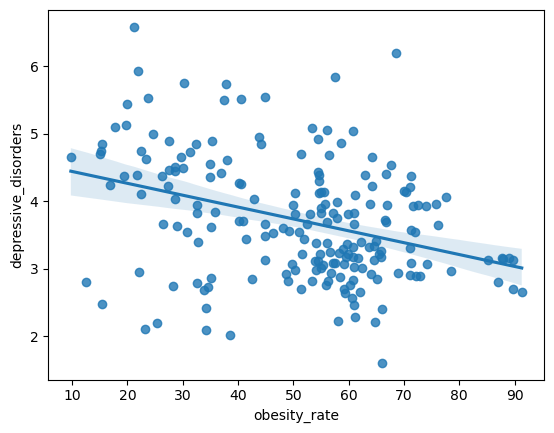

In [97]:
sns.regplot(data=df_2019, x="obesity_rate", y="depressive_disorders")

A weak negative association was observed between obesity and depression across countries. This suggests that higher obesity rates are not associated with higher depression at the country level, though this may be influenced by economic and reporting differences.

In [98]:
# Cross country examination
# Anxiety

df_2019 = obesity_mental_health_df[obesity_mental_health_df["year"] == 2019]
df_2019["obesity_rate"].corr(df_2019["anxiety_disorders"])

np.float64(0.2903450518248885)

<Axes: xlabel='obesity_rate', ylabel='anxiety_disorders'>

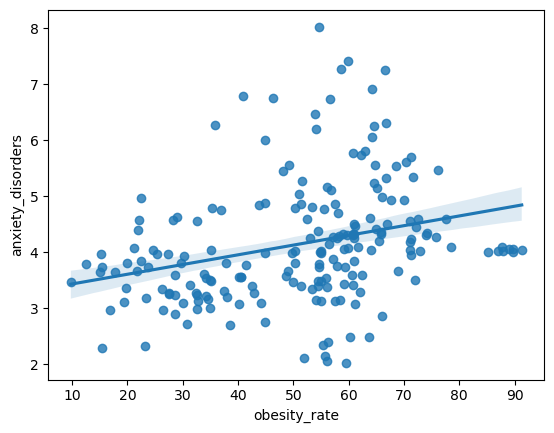

In [99]:
sns.regplot(data=df_2019, x="obesity_rate", y="anxiety_disorders")

We can see that at lower obesity levels, anxiety rates are relatively consistent on the lower side, while at higher obesity levels, variability increases significantly.

We will split tha data to see the correlation on the lower side

In [127]:
low = df_2019[df_2019["obesity_rate"] < 45]
high = df_2019[df_2019["obesity_rate"] >= 45]

# Anxiety
low["obesity_rate"].corr(low["anxiety_disorders"]), high["obesity_rate"].corr(high["anxiety_disorders"])


(np.float64(0.17194868356844153), np.float64(0.03553703514502382))

In [128]:
# Depression
low["obesity_rate"].corr(low["depressive_disorders"]), high["obesity_rate"].corr(high["depressive_disorders"])

(np.float64(-0.13773584383136772), np.float64(-0.12790550981122986))

The observed positive association between obesity and anxiety weakens significantly when the data is segmented, suggesting that the overall correlation may be driven by differences between groups rather than a consistent relationship. Looks like Simpson's Paradox.

In [119]:
# Overal correlation of all data (all countries + all years)
obesity_mental_health_df["obesity_rate"].corr(obesity_mental_health_df["anxiety_disorders"]), obesity_mental_health_df["obesity_rate"].corr(obesity_mental_health_df["depressive_disorders"])

(np.float64(0.32498132067784213), np.float64(-0.33538836608070394))

In [124]:
# Splitting by groups for the overall result

low = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] < 45]
high = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] >= 45]

In [125]:
# Anxiety
low["obesity_rate"].corr(low["anxiety_disorders"]), high["obesity_rate"].corr(high["anxiety_disorders"])


(np.float64(0.313673522416064), np.float64(-0.011951379000706724))

In [126]:

# Depression
low["obesity_rate"].corr(low["depressive_disorders"]), high["obesity_rate"].corr(high["depressive_disorders"])

(np.float64(-0.2785083488581019), np.float64(-0.13090237975656133))

The relationship between obesity and mental health varies depending on the level of aggregation. When analyzing a single year, the association weakens significantly after segmentation, while using multi-year data reveals a more stable but still weak relationship in lower obesity ranges.

##### 2nd Approach: Within-country exploration. When obesity increases in a country, does mental health also change?

In [183]:
obesity_mental_health_df.sort_values(["country", "year"])

,country,year,depressive_disorders,anxiety_disorders,obesity_rate
0,Afghanistan,1990,4.996118,4.713314,10.13355
1,Afghanistan,1991,4.989290,4.702100,10.73641
2,Afghanistan,1992,4.981346,4.683743,11.37092
3,Afghanistan,1993,4.976958,4.673549,12.03992
4,Afghanistan,1994,4.977782,4.670810,12.74325
...,...,...,...,...,...
5965,Zimbabwe,2015,3.407624,3.184012,30.72174
5966,Zimbabwe,2016,3.410755,3.187148,31.21832
5967,Zimbabwe,2017,3.411965,3.188418,31.72858
5968,Zimbabwe,2018,3.406929,3.172111,32.25148


In [184]:
obesity_mental_health_df["obesity_change"] = obesity_mental_health_df.groupby("country")["obesity_rate"].diff()
obesity_mental_health_df["anxiety_change"] = obesity_mental_health_df.groupby("country")["anxiety_disorders"].diff()
obesity_mental_health_df["depression_change"] = obesity_mental_health_df.groupby("country")["depressive_disorders"].diff()

In [185]:
obesity_mental_health_df["obesity_change"].corr(obesity_mental_health_df["anxiety_change"]), obesity_mental_health_df["obesity_change"].corr(obesity_mental_health_df["depression_change"])

(np.float64(-0.011056340740205142), np.float64(0.04684319571103189))

<Axes: xlabel='year', ylabel='obesity_rate'>

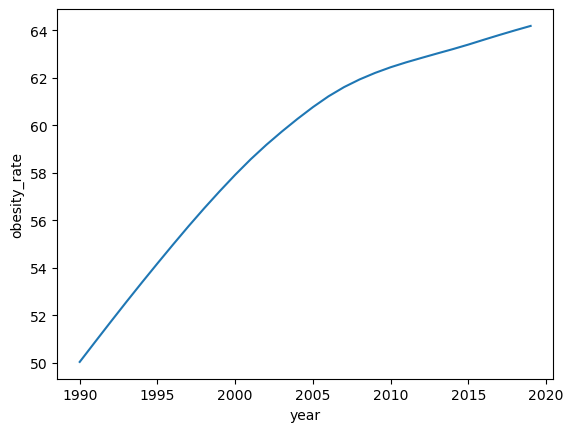

In [177]:
sns.lineplot(data=obesity_mental_health_df[obesity_mental_health_df["country"]=="Ireland"], x="year", y="obesity_rate")

<Axes: xlabel='year', ylabel='depressive_disorders'>

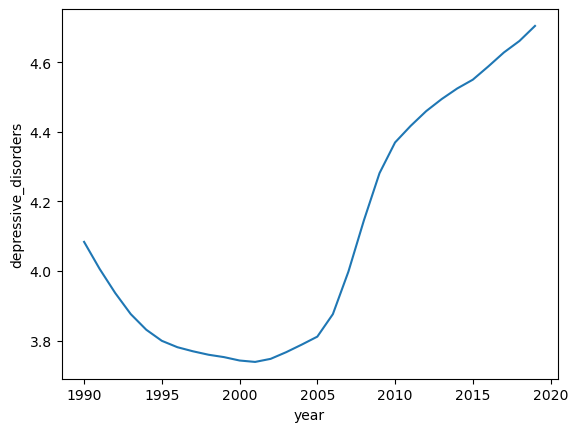

In [178]:
sns.lineplot(data=obesity_mental_health_df[obesity_mental_health_df["country"]=="Spain"], x="year", y="depressive_disorders")

In [149]:
obesity_mental_health_df['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', '

### Resources

https://en.wikipedia.org/wiki/Body_mass_index

https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html